# BBC document classification with GPT-2 (124M)

This notebook runs **zero-shot** evaluation, **generative fine-tuning** (loss only on label tokens), and **post fine-tune** evaluation on the BBC split under `data/bbc/{train,val,test}`.

**Hardware:** tuned for ~6GB VRAM (e.g. RTX 3060).

In [1]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (torch):", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    

Torch version: 2.5.1+cu121
CUDA available: True
CUDA version (torch): 12.1
GPU count: 1
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU


In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

_ROOT = Path("..").resolve()
_SRC = _ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

from llm_doc_classification.config import (
    bbc_data_dir,
    config_path_display,
    get_seed,
    gpt2_124m_preds_csv,
    gpt2_profile,
    paths,
)
from llm_doc_classification.data.bbc import BBC_LABELS, clean_bbc_splits, load_bbc_split
from llm_doc_classification.models.gpt2_bbc_generative import (
    BBCGenerativeDataset,
    EpochTimingAndGpuCallback,
    PadCollator,
    bbc_label_pattern,
    classification_metrics,
    generate_labels,
)
from llm_doc_classification.utils.seed import set_seed_all

# Paths / hyperparameters from `configs/default.json` (edit that file to change defaults)
_P = paths()
_G = gpt2_profile("124m")
DATA_ROOT = bbc_data_dir()
MODEL_OUT = _P["models"] / _G["finetune_model_subdir"]
TUNED_MODEL_OUT = _P["models"] / _G["eval_tuned_subdir"]
RESULTS_DIR = _P["results"]
PRED_CSV = gpt2_124m_preds_csv()
PRETRAINED = _G["pretrained"]
LABELS = list(BBC_LABELS)
LABEL_PATTERN = bbc_label_pattern()
MAX_LENGTH = _G["max_length"]
MAX_NEW_TOKENS = _G["max_new_tokens"]
SEED = get_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Config:", config_path_display())
print("Device:", device)
print("DATA_ROOT:", DATA_ROOT)
set_seed_all(SEED)

Device: cuda
DATA_ROOT: D:\llm_doc_classification\data\bbc


In [19]:
# (seed set in the config cell above; `llm_doc_classification.utils.seed`)
pass


In [6]:
train_df = load_bbc_split(DATA_ROOT, "train")
val_df = load_bbc_split(DATA_ROOT, "val")
test_df = load_bbc_split(DATA_ROOT, "test")
train_df, val_df, test_df = clean_bbc_splits(
    train_df, val_df, test_df, label2id=None
)
print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print(test_df["label"].value_counts().sort_index())

Loaded train from train.csv (no train/ folder found)
Loaded val from val.csv (no val/ folder found)
Loaded test from test.csv (no test/ folder found)
Train: (1780, 3) Val: (222, 3) Test: (223, 3)
label
business         51
entertainment    39
politics         42
sport            51
tech             40
Name: count, dtype: int64


In [10]:
# Prompts, truncation, and `generate_labels` live in
# `llm_doc_classification.models.gpt2_bbc_generative` (imported in the config cell).
pass

In [11]:
# (Inference loop is `generate_labels` in `llm_doc_classification.models.gpt2_bbc_generative`.)
pass

In [12]:
# STAGE 1 — Zero-shot (pre fine-tune)

tokenizer = AutoTokenizer.from_pretrained(PRETRAINED)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(PRETRAINED)
model.to(device)

zs_preds, zs_raw = generate_labels(
    model,
    tokenizer,
    test_df,
    device,
    labels=LABELS,
    label_pattern=LABEL_PATTERN,
    max_length=MAX_LENGTH,
    max_new_tokens=MAX_NEW_TOKENS,
)
zs_metrics = classification_metrics(test_df["label"].tolist(), zs_preds, labels=LABELS)

print("GPT-2 Zero-shot Results")
print(f"  accuracy: {zs_metrics['accuracy']:.4f}")
print(f"  macro_f1: {zs_metrics['macro_f1']:.4f}")
print(f"  weighted_f1: {zs_metrics['weighted_f1']:.4f}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generate:   0%|          | 0/223 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1669 > 1024). Running this sequence through the model will result in indexing errors


GPT-2 Zero-shot Results
  accuracy: 0.3857
  macro_f1: 0.3417
  weighted_f1: 0.3515


In case of multiple training and reseting

In [22]:
# Clean reset before training (for reproducible reruns)
model = AutoModelForCausalLM.from_pretrained(PRETRAINED).to(device)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [23]:
# STAGE 2 — Fine-tuning (loss only on label tokens)
set_seed_all(SEED)

from transformers import Trainer

train_ds = BBCGenerativeDataset(train_df, tokenizer, MAX_LENGTH)
val_ds = BBCGenerativeDataset(val_df, tokenizer, MAX_LENGTH)

MODEL_OUT.mkdir(parents=True, exist_ok=True)

use_fp16 = torch.cuda.is_available()
train_args = TrainingArguments(
    output_dir=str(MODEL_OUT),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=6,
    learning_rate=5e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=use_fp16,
    bf16=False,
    gradient_checkpointing=True,
    save_total_limit=2,
    seed=SEED,
    data_seed=SEED,
    dataloader_num_workers=0,
    report_to=[],
    disable_tqdm=False,
)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=PadCollator(tokenizer),
    callbacks=[EpochTimingAndGpuCallback()],
)

print("Starting Stage 2 training...")
trainer.train()
trainer.save_model(str(MODEL_OUT))
tokenizer.save_pretrained(str(MODEL_OUT))

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting Stage 2 training...

Epoch 1 started...


Epoch,Training Loss,Validation Loss
1,0.116542,0.181744
2,0.168399,0.065711
3,0.004026,0.129673
4,0.001262,0.108699
5,0.000002,0.111914
6,0.000001,0.113233


Epoch 1 training time: 227.93s
GPU usage (GB) - allocated: 3.74, reserved: 5.35, peak allocated: 4.84


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


Epoch 6 started...
Epoch 6 training time: 229.06s
GPU usage (GB) - allocated: 3.74, reserved: 5.35, peak allocated: 4.84


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('D:\\llm_doc_classification\\models\\gpt2_bbc\\tokenizer_config.json',
 'D:\\llm_doc_classification\\models\\gpt2_bbc\\tokenizer.json')

In [26]:
# Fine-tuning visualization prep (uses existing logs; no retraining)
import json
import re
import matplotlib.pyplot as plt

train_loss_df = pd.DataFrame()
val_loss_df = pd.DataFrame()
epoch_stats_df = pd.DataFrame()

if "trainer" in globals() and hasattr(trainer, "state"):
    hist_df = pd.DataFrame(trainer.state.log_history)
    if not hist_df.empty:
        train_loss_df = (
            hist_df[hist_df["loss"].notna()][["epoch", "loss"]]
            .dropna()
            .reset_index(drop=True)
        )
        val_loss_df = (
            hist_df[hist_df["eval_loss"].notna()][["epoch", "eval_loss"]]
            .dropna()
            .reset_index(drop=True)
        )

# Parse epoch timing + GPU usage from saved Stage 2 output text in this notebook file.
nb_path = Path("bbc_GPT2_124M.ipynb")
if not nb_path.exists():
    nb_path = Path("notebooks/bbc_GPT2_124M.ipynb")
if not nb_path.exists():
    nb_path = Path("../notebooks/bbc_GPT2_124M.ipynb")

if nb_path.exists():
    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    stage2_text = ""
    for c in nb.get("cells", []):
        src = "".join(c.get("source", []))
        if "# STAGE 2 — Fine-tuning" in src:
            for o in c.get("outputs", []):
                if o.get("output_type") == "stream":
                    stage2_text += "".join(o.get("text", []))

    time_matches = re.findall(r"Epoch (\d+) training time: ([\d.]+)s", stage2_text)
    gpu_matches = re.findall(
        r"GPU usage \(GB\) - allocated: ([\d.]+), reserved: ([\d.]+), peak allocated: ([\d.]+)",
        stage2_text,
    )

    if time_matches:
        epoch_stats_df = pd.DataFrame(time_matches, columns=["epoch", "epoch_time_s"])
        epoch_stats_df["epoch"] = epoch_stats_df["epoch"].astype(int)
        epoch_stats_df["epoch_time_s"] = epoch_stats_df["epoch_time_s"].astype(float)

        if len(gpu_matches) == len(epoch_stats_df):
            gdf = pd.DataFrame(
                gpu_matches,
                columns=["gpu_allocated_gb", "gpu_reserved_gb", "gpu_peak_allocated_gb"],
            ).astype(float)
            epoch_stats_df = pd.concat([epoch_stats_df, gdf], axis=1)

print("train_loss points:", len(train_loss_df))
print("val_loss points:", len(val_loss_df))
print("epoch stats rows:", len(epoch_stats_df))

train_loss points: 53
val_loss points: 6
epoch stats rows: 6


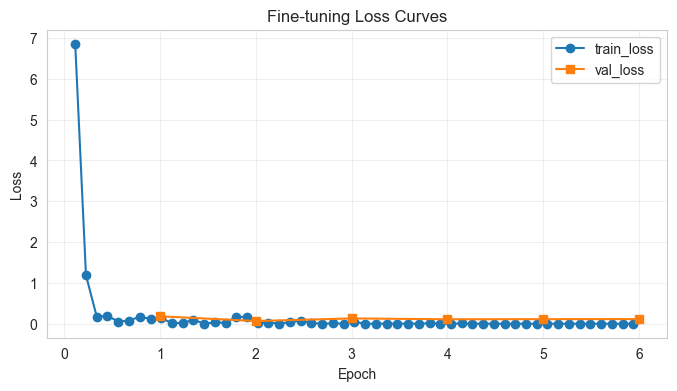

In [27]:
# Plot 1: Training and validation loss curves
plt.figure(figsize=(8, 4))

if not train_loss_df.empty:
    plt.plot(train_loss_df["epoch"], train_loss_df["loss"], marker="o", label="train_loss")
if not val_loss_df.empty:
    plt.plot(val_loss_df["epoch"], val_loss_df["eval_loss"], marker="s", label="val_loss")

plt.title("Fine-tuning Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
if (not train_loss_df.empty) or (not val_loss_df.empty):
    plt.legend()
plt.show()

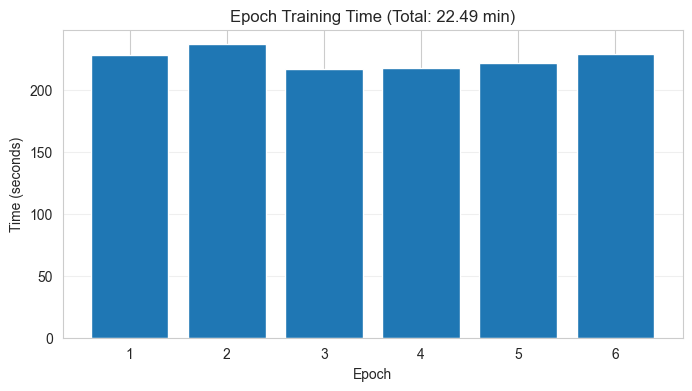

Total fine-tuning time: 1349.20 s (22.49 min)


In [28]:
# Plot 2: Epoch training time + total time
if epoch_stats_df.empty:
    print("No epoch timing data found in saved Stage 2 output.")
else:
    total_time_s = epoch_stats_df["epoch_time_s"].sum()

    plt.figure(figsize=(8, 4))
    plt.bar(epoch_stats_df["epoch"].astype(str), epoch_stats_df["epoch_time_s"])
    plt.title(f"Epoch Training Time (Total: {total_time_s/60:.2f} min)")
    plt.xlabel("Epoch")
    plt.ylabel("Time (seconds)")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    print(f"Total fine-tuning time: {total_time_s:.2f} s ({total_time_s/60:.2f} min)")

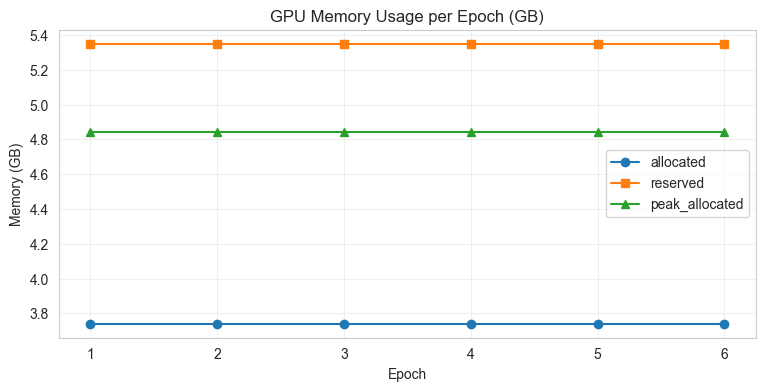

In [29]:
# Plot 3: GPU usage by epoch
if epoch_stats_df.empty or "gpu_peak_allocated_gb" not in epoch_stats_df.columns:
    print("No GPU usage data found in saved Stage 2 output.")
else:
    plt.figure(figsize=(9, 4))
    plt.plot(epoch_stats_df["epoch"], epoch_stats_df["gpu_allocated_gb"], marker="o", label="allocated")
    plt.plot(epoch_stats_df["epoch"], epoch_stats_df["gpu_reserved_gb"], marker="s", label="reserved")
    plt.plot(epoch_stats_df["epoch"], epoch_stats_df["gpu_peak_allocated_gb"], marker="^", label="peak_allocated")
    plt.title("GPU Memory Usage per Epoch (GB)")
    plt.xlabel("Epoch")
    plt.ylabel("Memory (GB)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [24]:
# Optional: save a named fine-tuned model artifact

TUNED_MODEL_OUT.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(TUNED_MODEL_OUT))
tokenizer.save_pretrained(str(TUNED_MODEL_OUT))

print("Fine-tuned model saved to:", TUNED_MODEL_OUT)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved to: D:\llm_doc_classification\models\gpt2_bbc_tuned


In [31]:
# STAGE 3 — Evaluate gpt2_bbc_tuned on test + save predictions

tokenizer_ft = AutoTokenizer.from_pretrained(str(TUNED_MODEL_OUT))
ft_model = AutoModelForCausalLM.from_pretrained(str(TUNED_MODEL_OUT)).to(device)

ft_preds, ft_raw = generate_labels(
    ft_model,
    tokenizer_ft,
    test_df,
    device,
    labels=LABELS,
    label_pattern=LABEL_PATTERN,
    max_length=MAX_LENGTH,
    max_new_tokens=MAX_NEW_TOKENS,
)
ft_metrics = classification_metrics(test_df["label"].tolist(), ft_preds, labels=LABELS)

print("GPT-2 Fine-tuned Results (gpt2_bbc_tuned on test)")
print(f"  accuracy: {ft_metrics['accuracy']:.4f}")
print(f"  macro_f1: {ft_metrics['macro_f1']:.4f}")
print(f"  weighted_f1: {ft_metrics['weighted_f1']:.4f}")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
pred_path = PRED_CSV
out_df = test_df[["path", "label"]].rename(columns={"label": "true_label"}).copy()
out_df["pred_zero_shot"] = zs_preds
out_df["pred_fine_tuned"] = ft_preds
out_df["raw_gen_zero_shot"] = zs_raw
out_df["raw_gen_fine_tuned"] = ft_raw
out_df.to_csv(pred_path, index=False)
print("Saved:", pred_path.resolve())

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generate:   0%|          | 0/223 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1669 > 1024). Running this sequence through the model will result in indexing errors


GPT-2 Fine-tuned Results (gpt2_bbc_tuned on test)
  accuracy: 0.9596
  macro_f1: 0.9571
  weighted_f1: 0.9591
Saved: D:\llm_doc_classification\results\gpt2_bbc_preds.csv


In [32]:
# Stage 3 visualization prep (uses existing Stage 3 outputs; no re-eval)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

viz_true = None
viz_pred = None

if "test_df" in globals() and "ft_preds" in globals() and len(ft_preds) == len(test_df):
    viz_true = test_df["label"].tolist()
    viz_pred = ft_preds
else:
    pred_csv = PRED_CSV
    if pred_csv.exists():
        _tmp = pd.read_csv(pred_csv)
        if {"true_label", "pred_fine_tuned"}.issubset(_tmp.columns):
            viz_true = _tmp["true_label"].astype(str).tolist()
            viz_pred = _tmp["pred_fine_tuned"].astype(str).tolist()

if viz_true is None or viz_pred is None:
    raise ValueError("Stage 3 predictions not found. Run Stage 3 cell first.")

viz_report = classification_report(
    viz_true,
    viz_pred,
    labels=LABELS,
    output_dict=True,
    zero_division=0,
)

viz_metrics = {
    "accuracy": float(viz_report["accuracy"]),
    "macro_precision": float(viz_report["macro avg"]["precision"]),
    "macro_recall": float(viz_report["macro avg"]["recall"]),
    "macro_f1": float(viz_report["macro avg"]["f1-score"]),
    "weighted_f1": float(viz_report["weighted avg"]["f1-score"]),
}

# Evaluation time is only shown if a timing variable exists from a timed run.
viz_eval_time_s = globals().get("stage3_eval_time_s", None)
if viz_eval_time_s is None:
    print("Evaluation time: not recorded in current notebook state.")
else:
    print(f"Evaluation time: {viz_eval_time_s:.2f} s")

Evaluation time: not recorded in current notebook state.


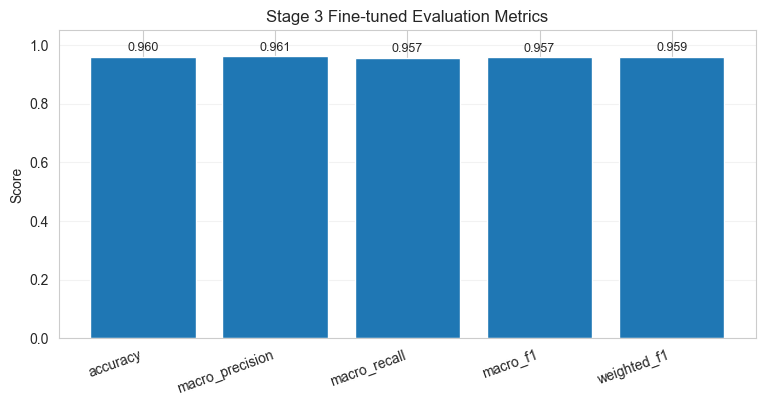

In [33]:
# Plot 1: Summary accuracy/evaluation metrics
metric_names = list(viz_metrics.keys())
metric_vals = [viz_metrics[k] for k in metric_names]

plt.figure(figsize=(9, 4))
plt.bar(metric_names, metric_vals)
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.ylabel("Score")
plt.title("Stage 3 Fine-tuned Evaluation Metrics")
for i, v in enumerate(metric_vals):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
plt.grid(axis="y", alpha=0.25)
plt.show()

if viz_eval_time_s is not None:
    plt.figure(figsize=(4, 4))
    plt.bar(["evaluation_time_s"], [viz_eval_time_s])
    plt.ylabel("Seconds")
    plt.title("Stage 3 Evaluation Time")
    plt.grid(axis="y", alpha=0.25)
    plt.show()

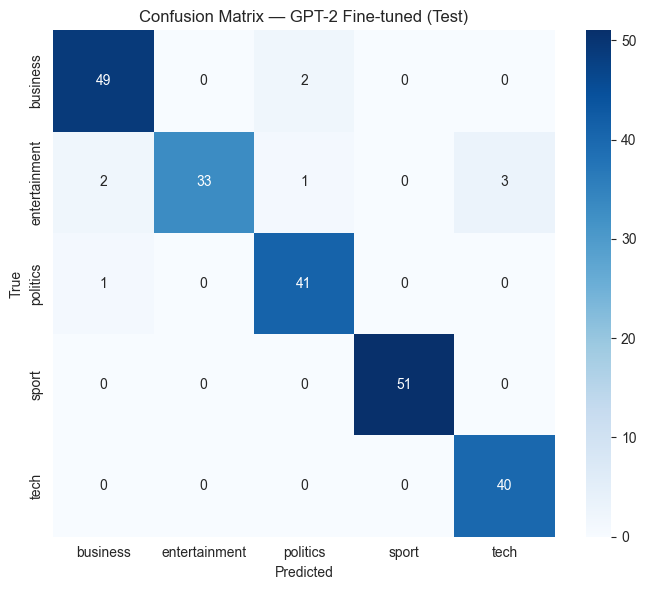

In [34]:
# Plot 2: Confusion matrix (fine-tuned predictions)
cm = confusion_matrix(viz_true, viz_pred, labels=LABELS)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — GPT-2 Fine-tuned (Test)")
plt.tight_layout()
plt.show()

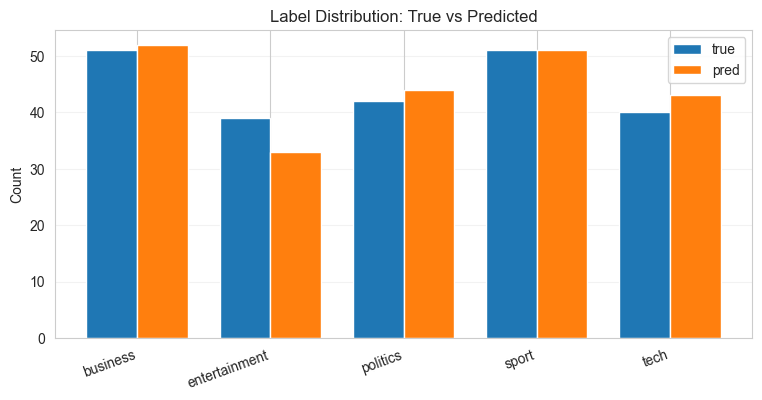

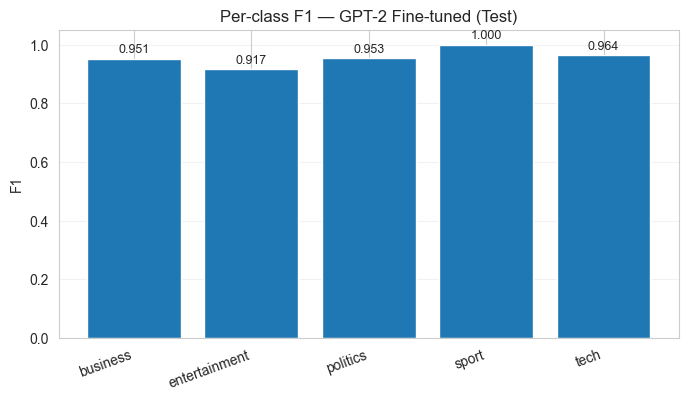

In [35]:
# Plot 3: True vs predicted label distribution + per-class F1
true_counts = pd.Series(viz_true).value_counts().reindex(LABELS, fill_value=0)
pred_counts = pd.Series(viz_pred).value_counts().reindex(LABELS, fill_value=0)

x = np.arange(len(LABELS))
width = 0.38

plt.figure(figsize=(9, 4))
plt.bar(x - width / 2, true_counts.values, width, label="true")
plt.bar(x + width / 2, pred_counts.values, width, label="pred")
plt.xticks(x, LABELS, rotation=20, ha="right")
plt.ylabel("Count")
plt.title("Label Distribution: True vs Predicted")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

class_f1 = [viz_report[label]["f1-score"] for label in LABELS]
plt.figure(figsize=(8, 4))
plt.bar(LABELS, class_f1)
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.ylabel("F1")
plt.title("Per-class F1 — GPT-2 Fine-tuned (Test)")
for i, v in enumerate(class_f1):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
plt.grid(axis="y", alpha=0.25)
plt.show()